In [3]:
import os
import glob
import shutil
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import ttest_ind
import seaborn as sns
from sklearn.decomposition import PCA
import nibabel.freesurfer.io as fsio
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import glob
import os
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind
from sklearn.metrics import pairwise_distances
import nibabel as nib
import sys
from nibabel import cifti2
from scipy.spatial import procrustes
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from natsort import natsorted
np.random.seed(42)

# Blind

## Jacobian Deformation

In [4]:
df = pd.read_csv('../Derivatives/blind_thalamus_log_jacobian_wholebrain_roi_values.csv')

2 -0.45243208037806065 0.654180574606426
4 -0.8713675620852609 0.3900572865582702
5 -1.0151093624933092 0.3177163737622098
6 -0.6568275773165722 0.5159892167185496
7 -1.0361365649852725 0.30809875024318445
8 -0.44421836813810833 0.6599367279961694
9 -4.232774157232671 0.00019933698971954622
10 -0.3776089830712771 0.7082399990046409
11 -1.1195691609264984 0.27126975566571765
12 -1.0590478809196422 0.2975323919171827
13 0.5549871387210948 0.5830857247969667
[0.70824    0.70824    0.69897602 0.70824    0.69897602 0.70824
 0.00219271 0.70824    0.69897602 0.69897602 0.70824   ]


/tmp/ipykernel_1702148/1704084239.py:164: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_1702148/1704084239.py:204: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(roi_labels, rotation=45, ha='right')


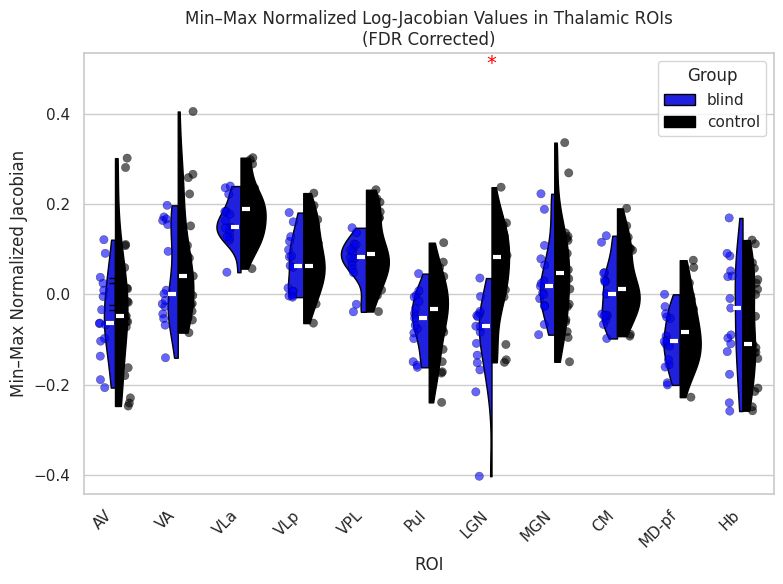

In [5]:
# ---------------------------------------------------------
# Define ROI subset and labels
# ---------------------------------------------------------
roi_subset = ['ROI_'+str(i) for i in [2,4,5,6,7,8,9,10,11,12,13]]
roi_labels = ['AV','VA','VLa','VLp', 'VPL', 'Pul','LGN', 'MGN','CM', 'MD-pf', 'Hb']

# ---------------------------------------------------------
# Melt long format
# ---------------------------------------------------------
df_melted = df.melt(
    id_vars=['subject', 'group'],
    value_vars=roi_subset,
    var_name='ROI',
    value_name='Jacobian'
)
df_melted['ROI'] = [int(x.replace('ROI_', '')) for x in df_melted['ROI']]
roi_subset = [2,4,5,6,7,8,9,10,11,12,13]
# ---------------------------------------------------------
# Normalize group names
# ---------------------------------------------------------
def map_group(g):
    if g.startswith(('eb', 'bl')):
        return 'blind'
    else:
        return 'control'

df_melted['group2'] = df_melted['group'].apply(map_group)

# ---------------------------------------------------------
# Min–max normalize per ROI
# ---------------------------------------------------------
def minmax_safe(x):
    return x
    #rng = x.max() - x.min()
    #if rng == 0:
    #    return pd.Series([0.0]*len(x), index=x.index)
    #return (x - x.min()) / rng

df_melted['Jacobian_norm'] = (
    df_melted.groupby('ROI')['Jacobian']
    .transform(minmax_safe)
)

# ---------------------------------------------------------
# Welch t-tests per ROI
# ---------------------------------------------------------
p_values = []

for roi in roi_subset:
    blind_vals = df_melted[
        (df_melted['ROI'] == roi) &
        (df_melted['group2'] == 'blind')
    ]['Jacobian_norm']

    ctrl_vals = df_melted[
        (df_melted['ROI'] == roi) &
        (df_melted['group2'] == 'control')
    ]['Jacobian_norm']

    stat, pval = ttest_ind(blind_vals, ctrl_vals, equal_var=False)
    print(roi, stat, pval)
    p_values.append(pval)

# ---------------------------------------------------------
# FDR correction
# ---------------------------------------------------------
reject, pvals_corrected, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method='fdr_bh'
)
print(pvals_corrected)

significant_rois = [
    roi for roi, sig in zip(roi_subset, reject) if sig
]

# ---------------------------------------------------------
# Compute mean and SEM manually
# ---------------------------------------------------------
summary = (
    df_melted
    .groupby(['ROI', 'group2'])['Jacobian_norm']
    .agg(['mean', 'sem'])
    .reset_index()
)

# ---------------------------------------------------------
# Plot: Barplot (means only)
# ---------------------------------------------------------
palette = {'blind': 'blue', 'control': 'black'}

sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))

ax = sns.violinplot(
    data=df_melted,
    x='ROI',
    y='Jacobian_norm',
    hue='group2',
    split=True,           # half violin
    inner=None,
    cut=0,
    linewidth=1,
    palette=palette
)

region_order = natsorted(df_melted['ROI'].unique())

# Compute medians
medians = (
    df_melted.groupby(['ROI', 'group2'])['Jacobian_norm']
    .median()
    .reset_index()
)

# Draw median lines
offset = 0.15  # adjust based on violin width

for i, region in enumerate(region_order):
    for group, sign in zip(['blind', 'control'], [-1, 1]):
        median = medians.loc[
            (medians['ROI'] == region) &
            (medians['group2'] == group),
            'Jacobian_norm'
        ].values[0]

        ax.hlines(
            y=median,
            xmin=i + sign*0.02,
            xmax=i + sign*offset,
            color='white',
            linewidth=3,
            zorder=10
        )

# ---------------------------------------------------------
# Add SEM error bars manually
# ---------------------------------------------------------
roi_positions = {roi: i for i, roi in enumerate(roi_subset)}

for bar, (_, row) in zip(ax.patches, summary.iterrows()):
    
    # Get bar center
    x = bar.get_x() + bar.get_width() / 2
    
    # Get bar height
    y = bar.get_height()
    
    # Add error bar
    ax.errorbar(
        x=x,
        y=y,
        yerr=row['sem'],
        fmt='none',
        ecolor='black',
        capsize=4,
        linewidth=1
    )

# ---------------------------------------------------------
# Scatter overlay
# ---------------------------------------------------------
sns.stripplot(
    data=df_melted,
    x='ROI',
    y='Jacobian_norm',
    hue='group2',
    dodge=True,
    jitter=True,
    alpha=0.6,
    size=6,
    edgecolor='gray',
    linewidth=0.3,
    palette=palette,
    ax=ax
)

# Remove duplicate legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Group')

# ---------------------------------------------------------
# Add significance stars
# ---------------------------------------------------------
ylim = ax.get_ylim()
y_offset = (ylim[1] - ylim[0]) * 0.05

for i, roi in enumerate(roi_subset):
    if roi in significant_rois:
        ax.text(
            i,
            ylim[1] + y_offset,
            '*',
            ha='center',
            va='bottom',
            color='red',
            fontsize=14
        )

# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------
ax.set_xticklabels(roi_labels, rotation=45, ha='right')

plt.ylabel("Min–Max Normalized Jacobian")
plt.title("Min–Max Normalized Log-Jacobian Values in Thalamic ROIs\n(FDR Corrected)")
plt.tight_layout()
plt.ylim([ylim[0], ylim[1] + 2*y_offset])
plt.show()

/tmp/ipykernel_1702148/2512090431.py:172: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


1 -4.157023637127581 0.00022484655871423388
2 -1.6379317773238835 0.11123342461628213
3 -1.13956060640181 0.26292792070414645
4 -0.9158957044510614 0.3665725430451531
5 -0.22585991740335107 0.8227467628774956


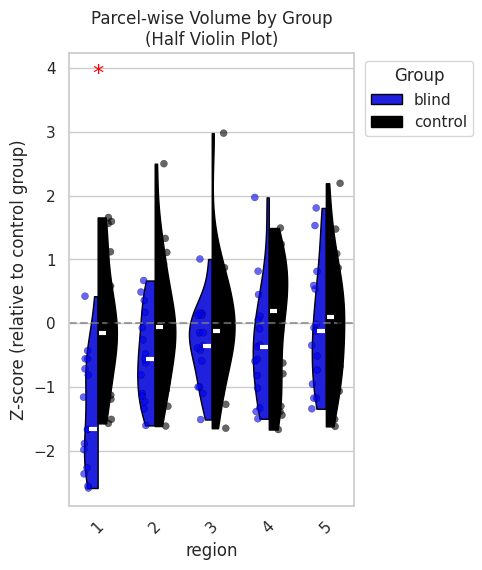

In [6]:
# -----------------------------------------------------------
# Load and prepare data
# -----------------------------------------------------------

parcel = pd.read_csv(
    '../Derivatives/roi_voxel_counts_per_parcel.tsv',
    sep='\t'
)

# Extract group code
parcel['group'] = [x[4:6] for x in parcel.Subject]

df_plot = parcel[
    ['ParcelLabel', 'Volume_mm3', 'group', 'Subject']
].copy()

df_plot = df_plot.rename(columns={
    'ParcelLabel': 'region',
    'Volume_mm3': 'value'
})

# -----------------------------------------------------------
# Normalize groups to blind / control
# -----------------------------------------------------------

def map_group(g):
    if g.startswith(('bl', 'eb')):
        return 'blind'
    else:
        return 'control'

df_plot['group2'] = df_plot['group'].apply(map_group)

# -----------------------------------------------------------
# Z-score normalization using CONTROL group
# -----------------------------------------------------------

control_stats = (
    df_plot[df_plot['group2'] == 'control']
    .groupby('region')['value']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={
        'mean': 'control_mean',
        'std': 'control_std'
    })
)

df_plot = df_plot.merge(
    control_stats,
    on='region',
    how='left'
)

df_plot['value_norm'] = (
    (df_plot['value'] - df_plot['control_mean']) /
    df_plot['control_std']
)

# -----------------------------------------------------------
# Region ordering
# -----------------------------------------------------------

region_order = natsorted(df_plot['region'].unique())

hue_order = ['blind', 'control']

palette = {
    'blind': 'blue',
    'control': 'black'
}

# -----------------------------------------------------------
# Compute t-tests
# -----------------------------------------------------------

p_values = []

for region in region_order:

    g1 = df_plot[
        (df_plot['region'] == region) &
        (df_plot['group2'] == 'blind')
    ]['value_norm']

    g2 = df_plot[
        (df_plot['region'] == region) &
        (df_plot['group2'] == 'control')
    ]['value_norm']

    stat, pval = ttest_ind(
        g1,
        g2,
        nan_policy='omit'
    )

    print(region, stat, pval)

    p_values.append(pval)

# -----------------------------------------------------------
# FDR correction
# -----------------------------------------------------------

reject, pvals_corrected, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method='fdr_bh'
)

sig_dict = {
    region: sig
    for region, sig in zip(region_order, reject)
}

# -----------------------------------------------------------
# Plot: Half violin + scatter
# -----------------------------------------------------------

sns.set(style="whitegrid")

plt.figure(figsize=(5, 6))

ax = sns.violinplot(
    data=df_plot,
    x='region',
    y='value_norm',
    hue='group2',
    order=region_order,
    hue_order=hue_order,
    split=True,
    inner=None,
    cut=0,
    linewidth=1,
    palette=palette
)

region_order = natsorted(df_plot['region'].unique())

# Compute medians
medians = (
    df_plot.groupby(['region', 'group2'])['value_norm']
    .median()
    .reset_index()
)

# Draw median lines
offset = 0.15  # adjust based on violin width

for i, region in enumerate(region_order):
    for group, sign in zip(['blind', 'control'], [-1, 1]):
        median = medians.loc[
            (medians['region'] == region) &
            (medians['group2'] == group),
            'value_norm'
        ].values[0]

        ax.hlines(
            y=median,
            xmin=i + sign*0.02,
            xmax=i + sign*offset,
            color='white',
            linewidth=3,
            zorder=10
        )


# -----------------------------------------------------------
# Scatter overlay
# -----------------------------------------------------------

sns.stripplot(
    data=df_plot,
    x='region',
    y='value_norm',
    hue='group2',
    order=region_order,
    hue_order=hue_order,
    dodge=True,
    jitter=True,
    alpha=0.6,
    size=5,
    edgecolor='gray',
    linewidth=0.3,
    palette=palette,
    ax=ax
)

# -----------------------------------------------------------
# Remove duplicate legend
# -----------------------------------------------------------

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[:2],
    labels[:2],
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    title='Group'
)

# -----------------------------------------------------------
# Add significance stars
# -----------------------------------------------------------

ylim = ax.get_ylim()

y_offset = (ylim[1] - ylim[0]) * 0.08

for i, region in enumerate(region_order):

    if sig_dict[region]:

        ax.text(
            i,
            ylim[1] + y_offset,
            '*',
            ha='center',
            va='bottom',
            fontsize=16,
            color='red'
        )

# -----------------------------------------------------------
# Final styling
# -----------------------------------------------------------

plt.axhline(
    0,
    linestyle='--',
    color='gray',
    alpha=0.7
)

plt.xticks(rotation=45)

plt.ylabel("Z-score (relative to control group)")

plt.title(
    "Parcel-wise Volume by Group\n(Half Violin Plot)"
)

plt.tight_layout()

plt.ylim([
    ylim[0],
    ylim[1] + 2*y_offset
])

plt.savefig(
    'pulsplit_half_violin_zscore.eps',
    format='eps'
)

plt.show()

## Thomas based thalamic nuclei segmentation

In [7]:
region_names = pd.read_csv('../Dataset/template/Wang/ROIfiles_Labeling.txt', sep='\t')
region_names = [x.split('- ')[1] for x in region_names.index.values]

/tmp/ipykernel_1702148/4049303683.py:96: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


2-AV -0.5615713687596119 0.5783202655881472
4-VA -0.5815450272113685 0.5649476229584742
5-VLa -1.4919543704582376 0.1455049032894406
6-VLP -1.3471552520403658 0.1873930581588446
7-VPL -1.716958672787698 0.09565262105216094
8-Pul -1.191744303474451 0.2421253183921331
9-LGN -4.195589777444152 0.0002015433982892786
10-MGN -1.183528675719547 0.2453175821538894
11-CM -0.9585759989583399 0.34495934427829944
12-MD-Pf -1.1877695745391668 0.24366589731359697


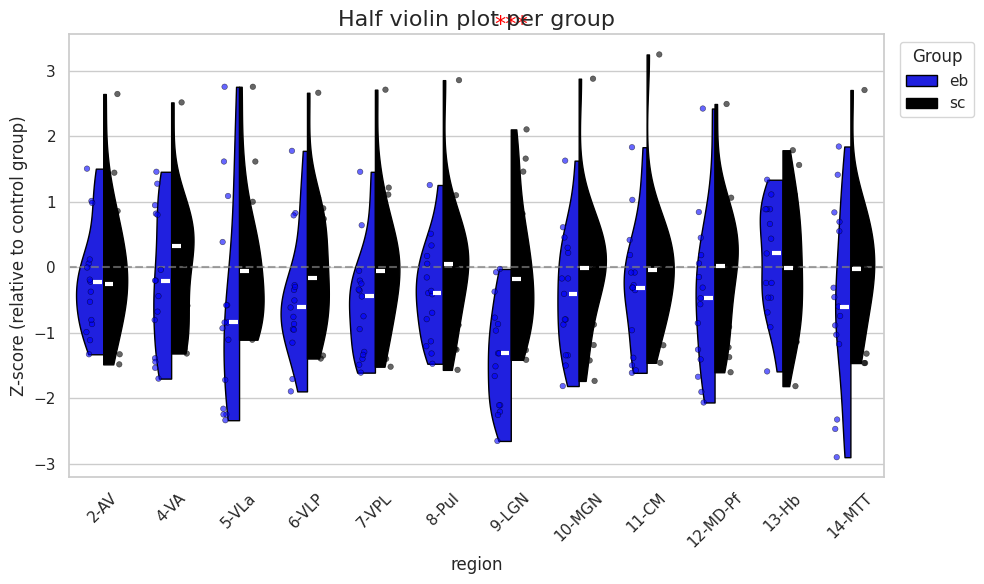

[0.57832027 0.57832027 0.35045369 0.35045369 0.35045369 0.35045369
 0.00201543 0.35045369 0.43119918 0.35045369]


In [8]:
sns.set(style="whitegrid")

# ---------------------------------------------------
# Step 1: Reshape data
# ---------------------------------------------------

df_all = pd.read_csv('../Derivatives/blind_thalamus_nuclei_volume.csv')

df_long = df_all.melt(
    id_vars=['Code', 'group'],
    value_vars=df_all.columns[:12],
    var_name='region',
    value_name='value'
)

df_long['value'] = pd.to_numeric(df_long['value'], errors='coerce')

df_avg = df_long.groupby(
    ['Code', 'group', 'region'],
    as_index=False
)['value'].mean()

# ---------------------------------------------------
# Step 2: Z-score using CONTROL group
# ---------------------------------------------------

control_label = 'sc'  # change if needed

control_stats = (
    df_avg[df_avg['group'] == control_label]
    .groupby('region')['value']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={
        'mean': 'control_mean',
        'std': 'control_std'
    })
)

df_avg = df_avg.merge(control_stats, on='region', how='left')

df_avg['value_norm'] = (
    (df_avg['value'] - df_avg['control_mean']) /
    df_avg['control_std']
)

# ---------------------------------------------------
# Step 3: Half violin plot
# ---------------------------------------------------

plt.figure(figsize=(10, 6))

region_order = natsorted(df_avg['region'].unique())

ax = sns.violinplot(
    data=df_avg,
    x='region',
    y='value_norm',
    hue='group',
    order=region_order,
    split=True,          # <- half violin
    inner=None,
    cut=0,
    linewidth=1,
    palette=['blue', 'black']
)

# Compute medians
medians = (
    df_avg.groupby(['region', 'group'])['value_norm']
    .median()
    .reset_index()
)

# Draw median lines
offset = 0.15  # adjust based on violin width

for i, region in enumerate(region_order):
    for group, sign in zip(['eb', 'sc'], [-1, 1]):
        median = medians.loc[
            (medians['region'] == region) &
            (medians['group'] == group),
            'value_norm'
        ].values[0]

        ax.hlines(
            y=median,
            xmin=i + sign*0.02,
            xmax=i + sign*offset,
            color='white',
            linewidth=3,
            zorder=10
        )

# Add individual points
sns.stripplot(
    data=df_avg,
    x='region',
    y='value_norm',
    hue='group',
    order=region_order,
    dodge=True,
    jitter=True,
    alpha=0.6,
    size=4,
    palette=['blue', 'black'],
    edgecolor='gray',
    linewidth=0.4
)

# Remove duplicate legends
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[:2],
    labels[:2],
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    title='Group'
)

# ---------------------------------------------------
# Step 4: Statistical tests
# ---------------------------------------------------

groups = df_avg['group'].unique()

y_max = df_avg['value_norm'].max()
pvals = []
for i, region in enumerate(region_order[:10]):

    group1 = df_avg[
        (df_avg['region'] == region) &
        (df_avg['group'] == groups[0])
    ]['value_norm']

    group2 = df_avg[
        (df_avg['region'] == region) &
        (df_avg['group'] == groups[1])
    ]['value_norm']

    stat, pval = ttest_ind(group1, group2, nan_policy='omit')

    pvals.append(pval)
    print(region, stat, pval)

    if pval < 0.001:
        sig = '***'
    elif pval < 0.01:
        sig = '**'
    elif pval < 0.05:
        sig = '*'
    else:
        sig = ''

    if sig:
        ax.text(
            i,
            y_max + 0.3,
            sig,
            ha='center',
            va='bottom',
            fontsize=16,
            color='red'
        )

# ---------------------------------------------------
# Final styling
# ---------------------------------------------------

plt.axhline(0, linestyle='--', color='gray', alpha=0.7)

plt.xticks(rotation=45)
plt.ylabel('Z-score (relative to control group)')
plt.title('Half violin plot per group', fontsize=16)

plt.tight_layout()
plt.savefig('blind_thalamus_half_violin_zscore.eps')

plt.show()

reject, pvals_corrected, _, _ = multipletests(
    pvals,
    alpha=0.05,
    method='fdr_bh'
)
print(pvals_corrected)

# Deaf

## Jacobian Deformation

In [9]:
deaf = pd.read_csv('../Dataset/fingerprint_FC_dataset/Deaf_deaf_subjects', header=None)
control = pd.read_csv('../Dataset/fingerprint_FC_dataset/Deaf_deaf_control_subjects', header=None)

In [10]:
df = pd.read_csv('../Derivatives/deaf_thalamus_log_jacobian_wholebrain_roi_values.csv')
df['group'] = ['deaf' if x in deaf[0].values else 'control' for x in df.subject]

/tmp/ipykernel_1702148/2104814124.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(roi_labels, rotation=45, ha='right')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


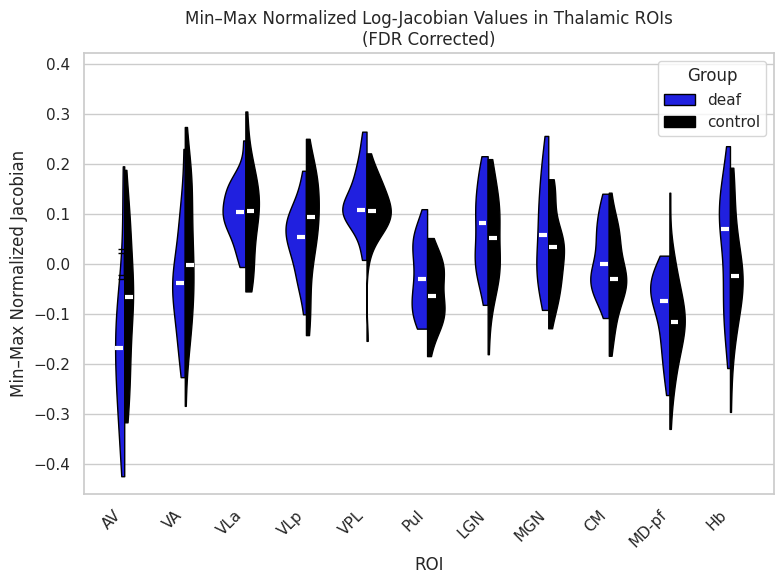

In [11]:
# ---------------------------------------------------------
# Define ROI subset and labels
# ---------------------------------------------------------
roi_subset = ['ROI_'+str(i) for i in [2,4,5,6,7,8,9,10,11,12,13]]
roi_labels = ['AV','VA','VLa','VLp', 'VPL', 'Pul','LGN', 'MGN','CM', 'MD-pf', 'Hb']

# ---------------------------------------------------------
# Melt long format
# ---------------------------------------------------------
df_melted = df.melt(
    id_vars=['subject', 'group'],
    value_vars=roi_subset,
    var_name='ROI',
    value_name='Jacobian'
)
df_melted['ROI'] = [int(x.replace('ROI_', '')) for x in df_melted['ROI']]
roi_subset = [2,4,5,6,7,8,9,10,11,12,13]

# ---------------------------------------------------------
# Normalize group names
# ---------------------------------------------------------
def map_group(g):
    if g.startswith(('de')):
        return 'deaf'
    else:
        return 'control'

df_melted['group2'] = df_melted['group'].apply(map_group)

# ---------------------------------------------------------
# Min–max normalize per ROI
# ---------------------------------------------------------
def minmax_safe(x):
    return x
    #rng = x.max() - x.min()
    #if rng == 0:
    #    return pd.Series([0.0]*len(x), index=x.index)
    #return (x - x.min()) / rng

df_melted['Jacobian_norm'] = (
    df_melted.groupby('ROI')['Jacobian']
    .transform(minmax_safe)
)

# ---------------------------------------------------------
# Welch t-tests per ROI
# ---------------------------------------------------------
p_values = []

for roi in roi_subset:
    blind_vals = df_melted[
        (df_melted['ROI'] == roi) &
        (df_melted['group2'] == 'deaf')
    ]['Jacobian_norm']

    ctrl_vals = df_melted[
        (df_melted['ROI'] == roi) &
        (df_melted['group2'] == 'control')
    ]['Jacobian_norm']

    stat, pval = ttest_ind(blind_vals, ctrl_vals, equal_var=False)
    p_values.append(pval)

# ---------------------------------------------------------
# FDR correction
# ---------------------------------------------------------
reject, pvals_corrected, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method='fdr_bh'
)

significant_rois = [
    roi for roi, sig in zip(roi_subset, reject) if sig
]

# ---------------------------------------------------------
# Compute mean and SEM manually
# ---------------------------------------------------------
summary = (
    df_melted
    .groupby(['ROI', 'group2'])['Jacobian_norm']
    .agg(['mean', 'sem'])
    .reset_index()
)

# ---------------------------------------------------------
# Plot: Barplot (means only)
# ---------------------------------------------------------
palette = {'deaf': 'blue', 'control': 'black'}

sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))

hue_order = ['deaf', 'control']

ax = sns.violinplot(
    data=df_melted,
    x='ROI',
    y='Jacobian_norm',
    hue='group2',
    split=True,           # half violin
    inner=None,
    cut=0,
    linewidth=1,
    palette=palette
)

region_order = natsorted(df_melted['ROI'].unique())

# Compute medians
medians = (
    df_melted.groupby(['ROI', 'group2'])['Jacobian_norm']
    .median()
    .reset_index()
)

# Draw median lines
offset = 0.15  # adjust based on violin width

for i, region in enumerate(region_order):
    for group, sign in zip(['deaf', 'control'], [-1, 1]):
        median = medians.loc[
            (medians['ROI'] == region) &
            (medians['group2'] == group),
            'Jacobian_norm'
        ].values[0]

        ax.hlines(
            y=median,
            xmin=i + sign*0.02,
            xmax=i + sign*offset,
            color='white',
            linewidth=3,
            zorder=10
        )

# ---------------------------------------------------------
# Add SEM error bars manually
# ---------------------------------------------------------
roi_positions = {roi: i for i, roi in enumerate(roi_subset)}

for bar, (_, row) in zip(ax.patches, summary.iterrows()):
    
    # Get bar center
    x = bar.get_x() + bar.get_width() / 2
    
    # Get bar height
    y = bar.get_height()
    
    # Add error bar
    ax.errorbar(
        x=x,
        y=y,
        yerr=row['sem'],
        fmt='none',
        ecolor='black',
        capsize=4,
        linewidth=1
    )

# Remove duplicate legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Group')

# ---------------------------------------------------------
# Add significance stars
# ---------------------------------------------------------
ylim = ax.get_ylim()
y_offset = (ylim[1] - ylim[0]) * 0.05

for i, roi in enumerate(roi_subset):
    if roi in significant_rois:
        ax.text(
            i,
            ylim[1] + y_offset,
            '*',
            ha='center',
            va='bottom',
            color='red',
            fontsize=14
        )

# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------
ax.set_xticklabels(roi_labels, rotation=45, ha='right')

plt.ylabel("Min–Max Normalized Jacobian")
plt.title("Min–Max Normalized Log-Jacobian Values in Thalamic ROIs\n(FDR Corrected)")
plt.tight_layout()
plt.ylim([ylim[0], ylim[1] + 2*y_offset])

plt.savefig('deformation_deaf.eps', format='eps')
plt.show()